<a href="https://colab.research.google.com/github/joniquechan/Project1/blob/master/Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generate a truth table for A AND !B where:


|  A  |  B  |  !B  |  \( A AND !B )  |
|:---:|:---:|:--------------:|:---------------------:|
|  0  |  0  |        1       |           0           |
|  0  |  1  |        0       |           0           |
|  1  |  0  |        1       |           1           |
|  1  |  1  |        0       |           0           |


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# truth table
data = [[0,0], [0,1], [1,0], [1,1]]
labels = [0, 0, 1, 0]

Scatter plot of the A AND !B truth table

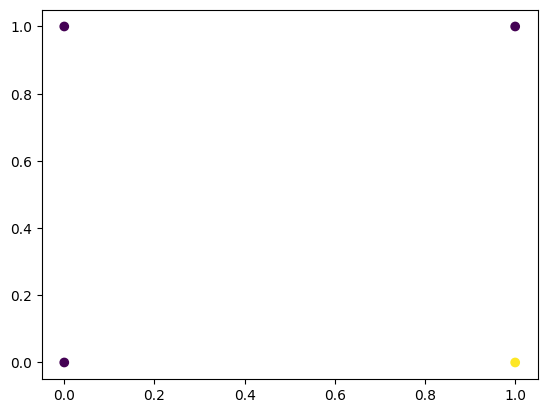

In [ ]:
plt.scatter([point[0] for point in data], [point[1] for point in data], c = labels)
plt.show()

To train the perceptron, we use an algorithm which essentially follows the equation: **z = w * x + b**
where x is the input, w is the weight, b is the bias term, and z is the weighted sum.

We start by initializing the w and b to small values and choose a learning rate, then we compute the prediction based on the above equation and compare the output (weighted sum) to the desired value (label). If the output differs from the desired value, we then update w and b to make the decision boundary move closer to the correct classification. This process is repeated for a fixed number of iterations (100 times in this case) or until there are no more errors.

In the code below, we also initialize an array of errors to keep track of the error improvement over each iteration.



In [ ]:
# initialize weights and bias

# bias
w0 = 0.1
# weights
w1 = 0.1
w2 = 0.1
output = 0
learning_rate = 0.001
errors = []

for iter in range(100):
  total_error = 0

  for i in range(len(data)):
    x1, x2 = data[i] # inputs
    t = labels[i] # target output

    # calculate net input
    net_input = w1 * x1 + w2 * x2 + w0

    if net_input > 0:
      output = 1
    else:
      output = 0

    # get error
    error = t - output
    total_error += abs(error)

    # update weights and bias
    if labels[i] != output:
      w0 += learning_rate * error
      w1 += learning_rate * error * x1
      w2 += learning_rate * error * x2

  # record error
  errors.append(total_error)


To plot the heatmap and to graph the error improvement, we create 100 evenly spaced values between 0 and 1 for each axis and a list of x and y values to represent a grid point. Then, we iterate through each grid point, computing the weighted sum of each input and storing the outputs into a list.

To visualize the error improvement, we create a plot of the errors that were collected earlier.

To visualize the perceptron's decision boundary, we create a heatmap by first reshaping the output list and then creating a heatmap from the reshaped outputs.

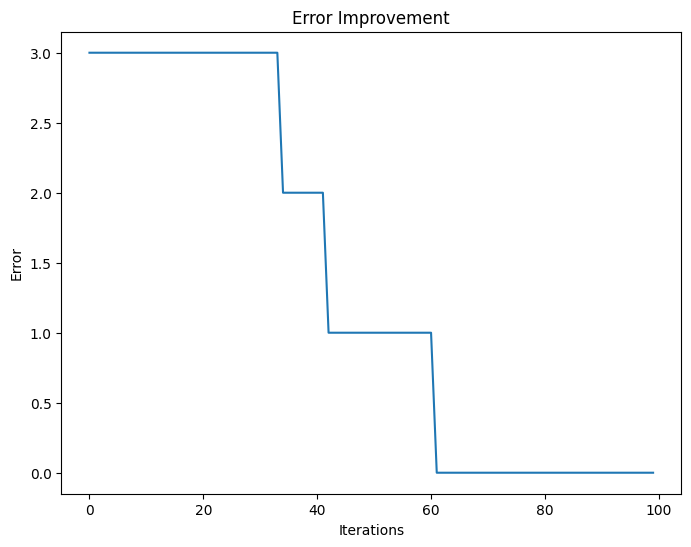

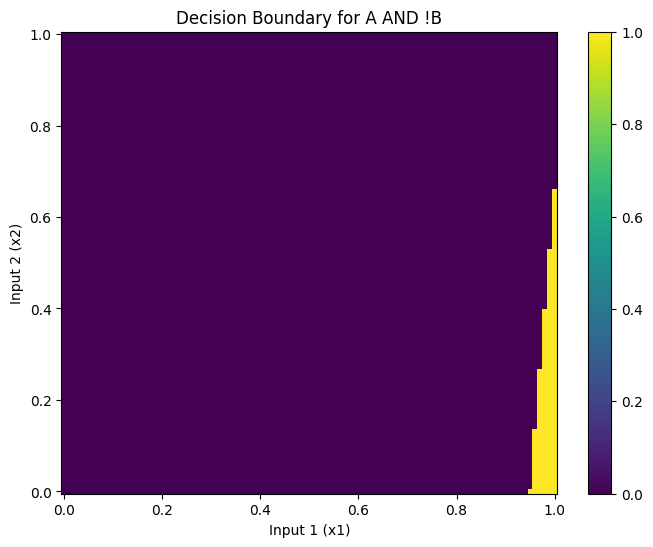

In [ ]:
from itertools import product

x_values = np.linspace(0, 1, 100)
y_values = np.linspace(0, 1, 100)

point_grid = list(product(x_values, y_values))

outputs = []
for input1, input2 in point_grid:
  net_input = w0 + w1 * input1 + w2 * input2
  if net_input > 0:
    output = 1
  else:
    output = 0
  outputs.append(output)

# error plot
plt.figure(figsize=(8,6))
plt.plot(range(len(errors)), errors)
plt.title('Error Improvement')
plt.xlabel('Iterations')
plt.ylabel('Error')
plt.show()

# heatmap
dist_matrix = np.reshape(outputs, (100,100), order='F')
plt.figure(figsize=(8,6))
heatmap = plt.pcolormesh(x_values, y_values, dist_matrix)
plt.colorbar(heatmap)
plt.title('Decision Boundary for A AND !B')
plt.xlabel('Input 1 (x1)')
plt.ylabel('Input 2 (x2)')
plt.show()